Shape: (27800, 10)

Column types:
 date               object
position            int64
song               object
artist             object
popularity          int64
duration_ms         int64
album_type         object
total_tracks        int64
is_explicit          bool
album_cover_url    object
dtype: object

Duplicate rows: 10
Missing values:
 date               0
position           0
song               0
artist             0
popularity         0
duration_ms        0
album_type         0
total_tracks       0
is_explicit        0
album_cover_url    0
duration_min       0
month              0
weekday            0
year               0
dur_bucket         0
dtype: int64

Date range: 2024-05-18 to 2025-11-27
Unique songs: 943
Unique artists: 297

── Numeric Summary ──
       position  popularity  duration_min  total_tracks
count  27800.00    27800.00      27800.00      27800.00
mean      25.50       87.67          3.31         12.94
std       14.43       10.46          0.80          9.46
min

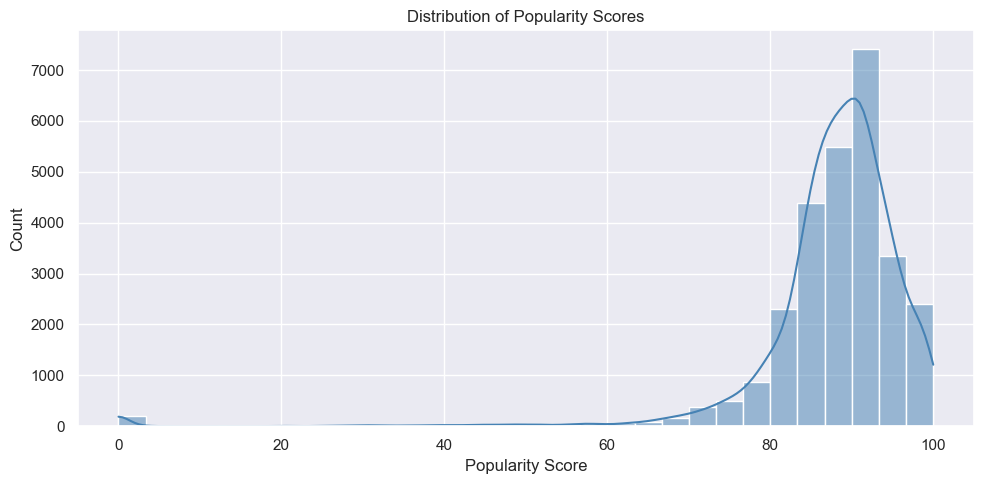

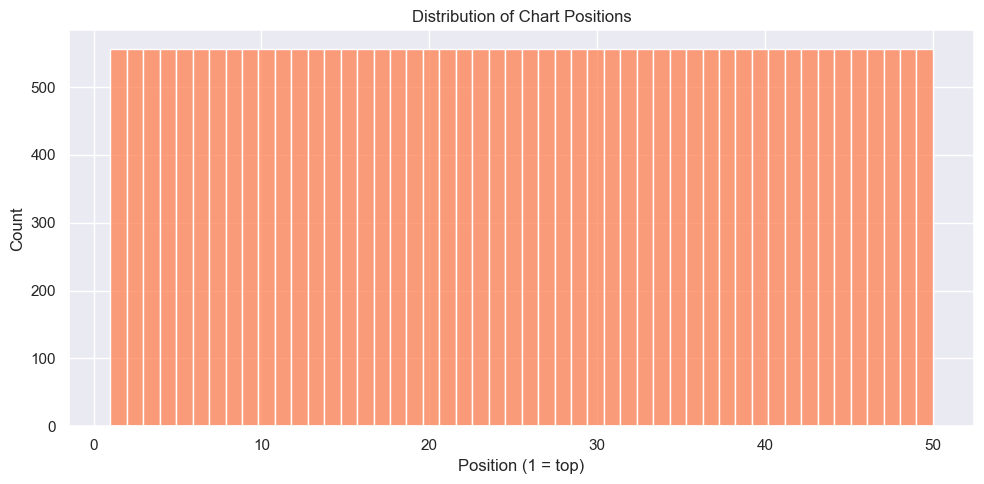

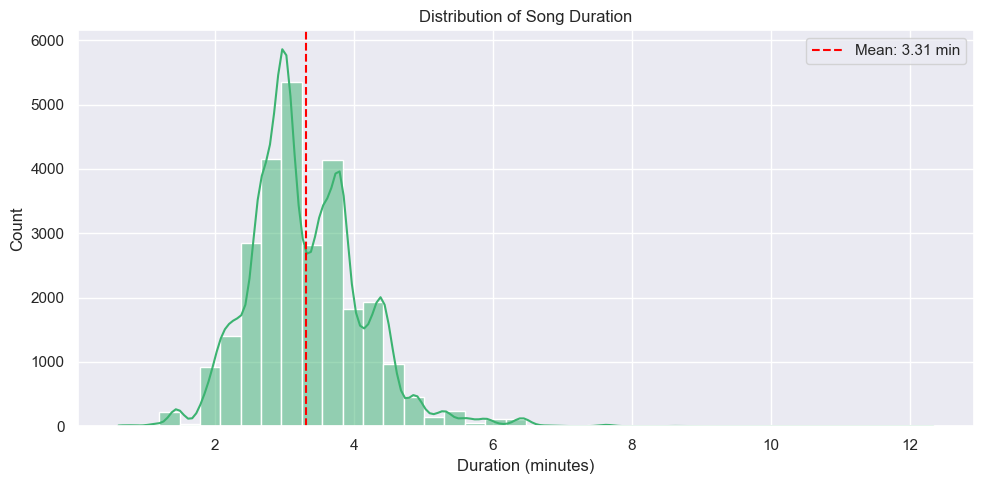

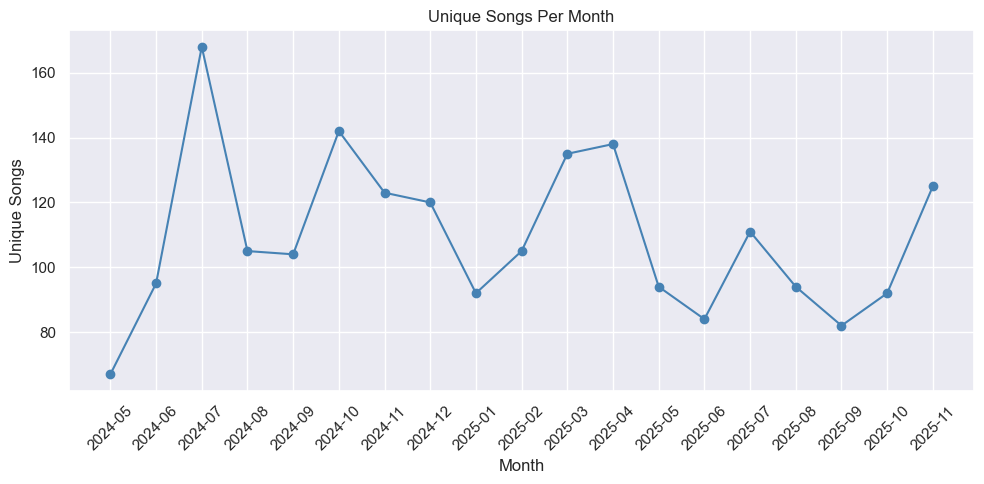

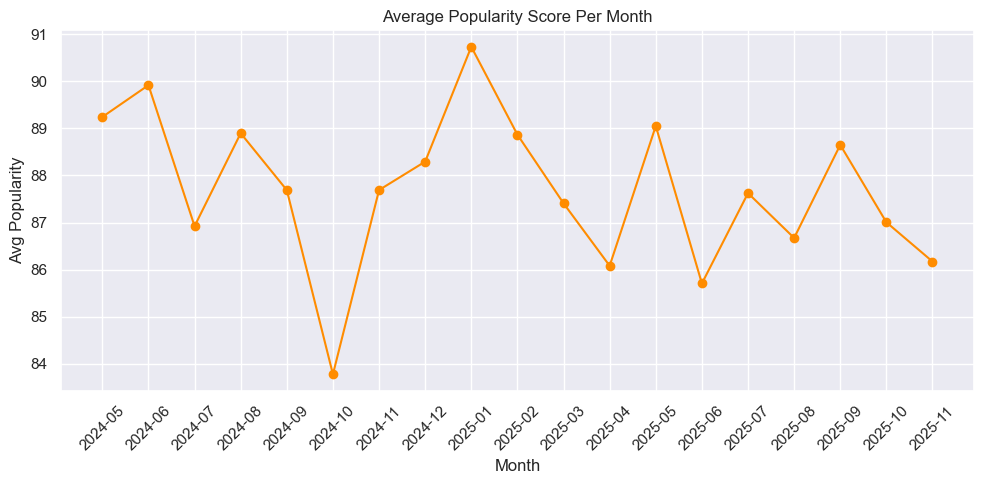

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21892\1965314157.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_artists, x="total_days", y="artist", palette="viridis")


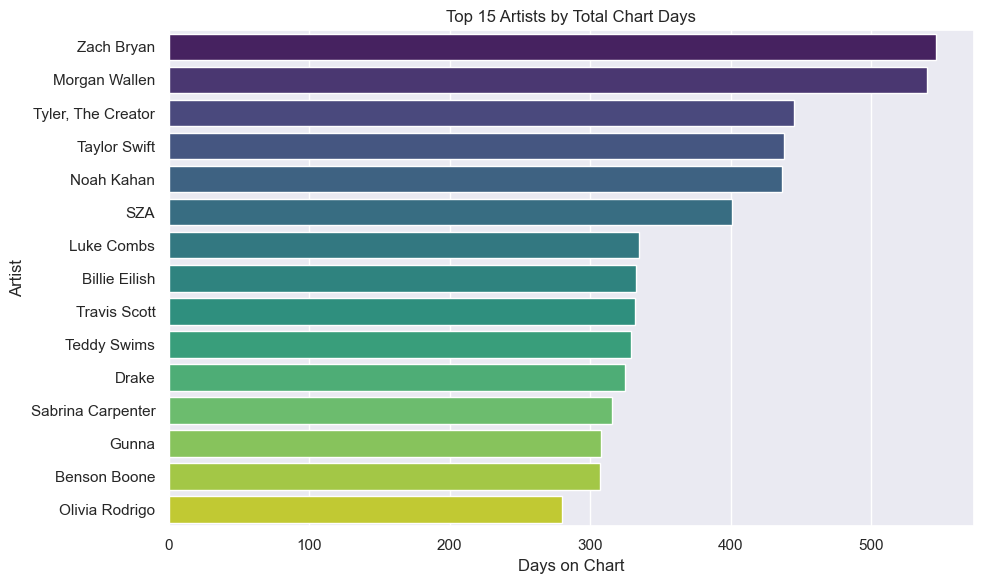

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21892\1965314157.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_by_songs, x="unique_songs", y="artist", palette="magma")


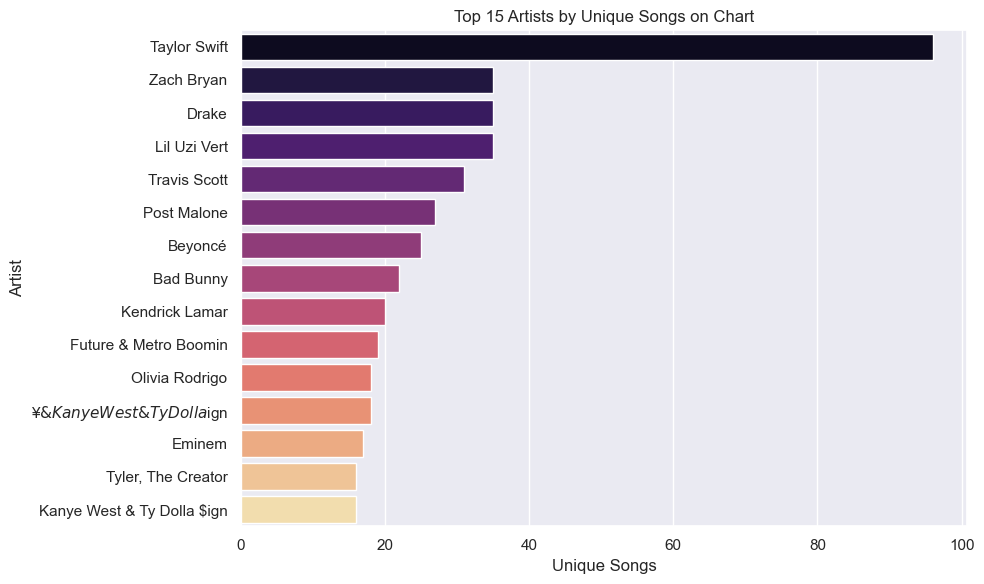

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21892\1965314157.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_songs, x="days_on_chart", y="label", palette="YlOrRd_r")


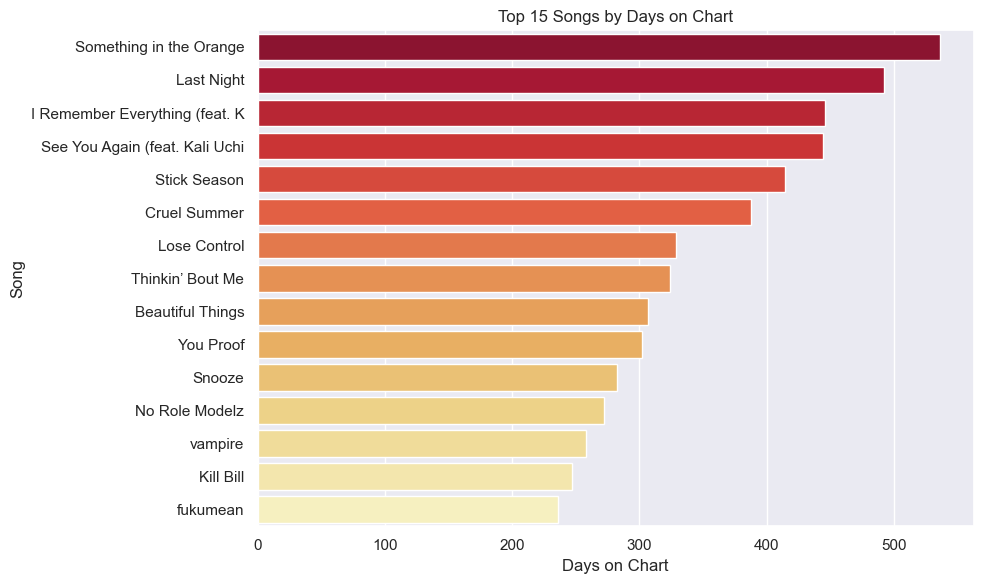

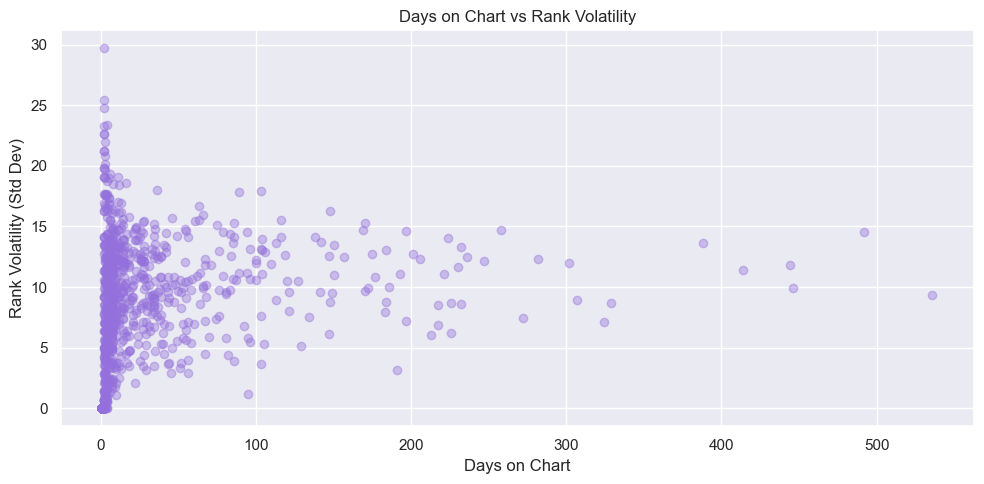

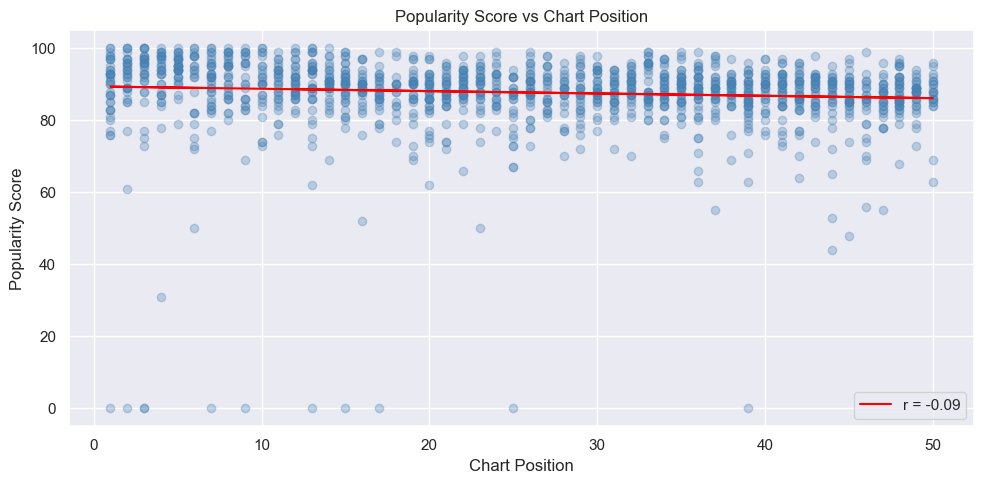


Correlation (popularity vs position): r = -0.092, p = 0.0004


C:\Users\Administrator\AppData\Local\Temp\ipykernel_21892\1965314157.py:228: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="rank_tier", y="popularity", palette="coolwarm")


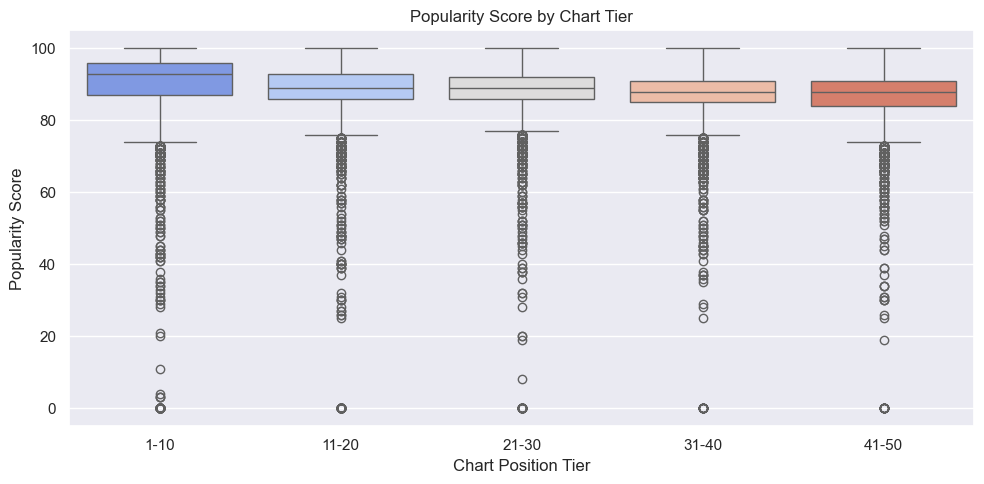


── Explicit vs Clean Performance ──
          popularity  position
Clean          87.99     25.59
Explicit       87.31     25.40


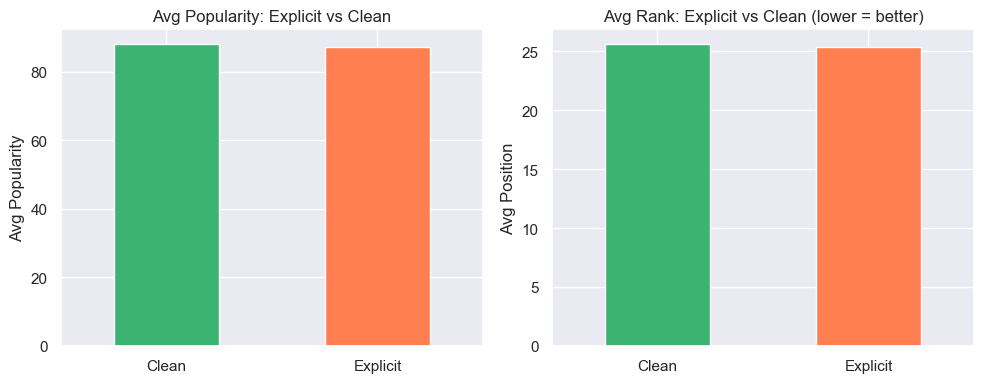

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21892\1965314157.py:260: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=alb, x="album_type", y="popularity", palette="Set2")


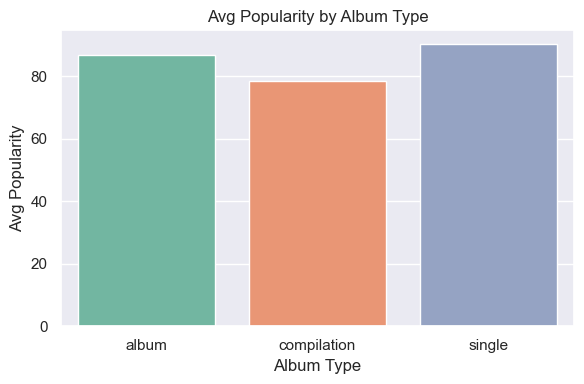

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21892\1965314157.py:271: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dur, x="dur_bucket", y="popularity", palette="Blues_d")


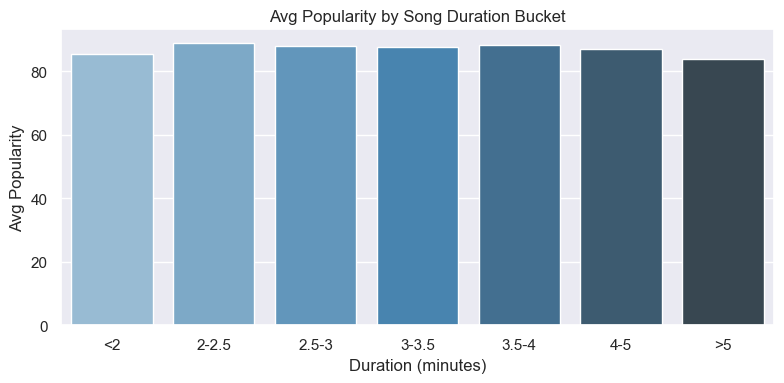

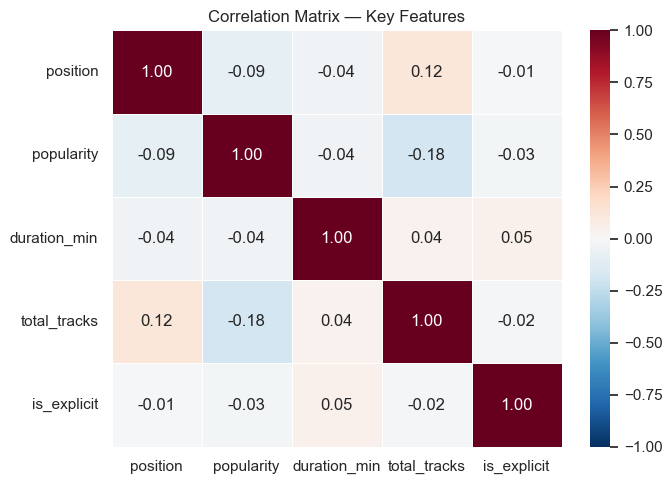


── Correlation with Popularity ──
total_tracks   -0.18
position       -0.09
duration_min   -0.04
is_explicit    -0.03
Name: popularity, dtype: float64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_21892\1965314157.py:303: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wd, x="weekday", y="popularity", palette="muted")


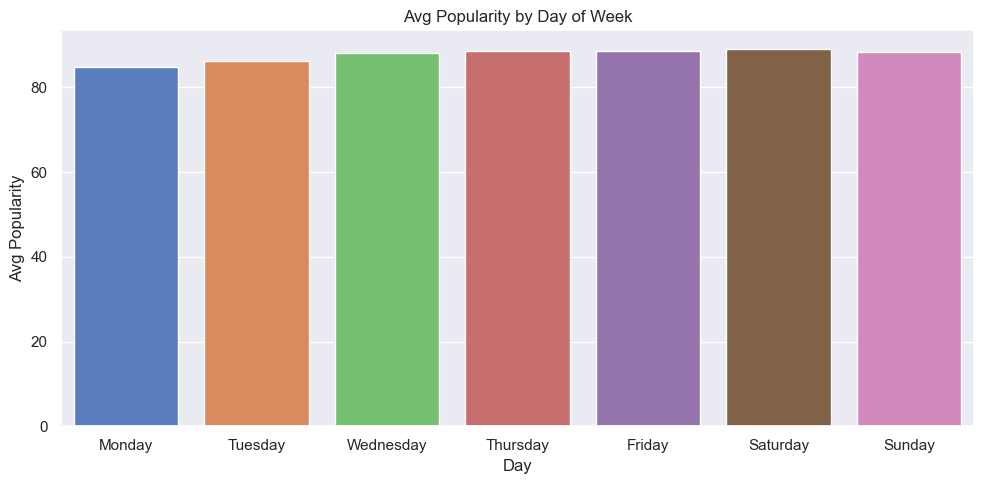


KEY FINDINGS
Total records        : 27,800
Date range           : 2024-05-18 to 2025-11-27
Unique songs         : 943
Unique artists       : 297
Avg popularity score : 87.7
Explicit share       : 48.0%
Most days on chart   : Something in the Orange (536 days)
Top artist (days)    : Zach Bryan (546 days)
Avg song duration    : 3.31 min
Pop-Rank correlation : -0.090


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── general plot style ──
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# =============================================================
# 1. LOAD DATA
# =============================================================
df = pd.read_csv(r"C:\Project(Unified Mentor)\Atlantic_United_States.csv")
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)

# =============================================================
# 2. DATA CLEANING & FEATURE ENGINEERING
# =============================================================
df["date"]         = pd.to_datetime(df["date"], dayfirst=True)
df["duration_min"] = (df["duration_ms"] / 60000).round(2)
df["month"]        = df["date"].dt.to_period("M").astype(str)
df["weekday"]      = df["date"].dt.day_name()
df["year"]         = df["date"].dt.year

# duration buckets for grouping
df["dur_bucket"] = pd.cut(
    df["duration_min"],
    bins=[0, 2, 2.5, 3, 3.5, 4, 5, 99],
    labels=["<2", "2-2.5", "2.5-3", "3-3.5", "3.5-4", "4-5", ">5"]
)

print("\nDuplicate rows:", df.duplicated().sum())
print("Missing values:\n", df.isnull().sum())
print("\nDate range:", df["date"].min().date(), "to", df["date"].max().date())
print("Unique songs:", df["song"].nunique())
print("Unique artists:", df["artist"].nunique())

# =============================================================
# 3. BASIC STATISTICS
# =============================================================
print("\n── Numeric Summary ──")
print(df[["position", "popularity", "duration_min", "total_tracks"]].describe().round(2))

print("\n── Album Type Distribution ──")
print(df["album_type"].value_counts())

print("\n── Explicit Content ──")
print(df["is_explicit"].value_counts())
print(f"Explicit share: {df['is_explicit'].mean()*100:.1f}%")

# =============================================================
# 4. SONG-LEVEL METRICS
# =============================================================
song_stats = df.groupby(["song", "artist"]).agg(
    days_on_chart  = ("date",        "nunique"),
    avg_rank       = ("position",    "mean"),
    best_rank      = ("position",    "min"),
    rank_volatility= ("position",    "std"),
    avg_popularity = ("popularity",  "mean"),
    album_type     = ("album_type",  "first"),
    is_explicit    = ("is_explicit", "first")
).reset_index().fillna({"rank_volatility": 0})
song_stats[["avg_rank", "avg_popularity", "rank_volatility"]] = \
    song_stats[["avg_rank", "avg_popularity", "rank_volatility"]].round(2)

print("\n── Top 10 Songs by Days on Chart ──")
print(song_stats.nlargest(10, "days_on_chart")
      [["song", "artist", "days_on_chart", "avg_rank", "best_rank", "avg_popularity"]].to_string(index=False))

# =============================================================
# 5. ARTIST-LEVEL METRICS
# =============================================================
artist_stats = df.groupby("artist").agg(
    total_days   = ("date",      "nunique"),
    unique_songs = ("song",      "nunique"),
    avg_rank     = ("position",  "mean"),
    avg_pop      = ("popularity","mean")
).reset_index().round(2).sort_values("total_days", ascending=False)

print("\n── Top 10 Artists by Chart Days ──")
print(artist_stats.head(10).to_string(index=False))

# =============================================================
# 6. DISTRIBUTION PLOTS
# =============================================================

# 6a. Popularity distribution
plt.figure()
sns.histplot(df["popularity"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Popularity Scores")
plt.xlabel("Popularity Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("fig_popularity_dist.png")
plt.show()

# 6b. Chart position distribution
plt.figure()
sns.histplot(df["position"], bins=50, color="coral")
plt.title("Distribution of Chart Positions")
plt.xlabel("Position (1 = top)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("fig_position_dist.png")
plt.show()

# 6c. Duration distribution
plt.figure()
sns.histplot(df["duration_min"], bins=40, kde=True, color="mediumseagreen")
plt.title("Distribution of Song Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.axvline(df["duration_min"].mean(), color="red", linestyle="--",
            label=f"Mean: {df['duration_min'].mean():.2f} min")
plt.legend()
plt.tight_layout()
plt.savefig("fig_duration_dist.png")
plt.show()

# =============================================================
# 7. CHART TRENDS OVER TIME
# =============================================================

# 7a. Unique songs per month
monthly = df.groupby("month")["song"].nunique().reset_index(name="unique_songs")
plt.figure()
plt.plot(monthly["month"], monthly["unique_songs"], marker="o", color="steelblue")
plt.xticks(rotation=45)
plt.title("Unique Songs Per Month")
plt.xlabel("Month")
plt.ylabel("Unique Songs")
plt.tight_layout()
plt.savefig("fig_monthly_songs.png")
plt.show()

# 7b. Avg popularity per month
monthly_pop = df.groupby("month")["popularity"].mean().reset_index()
plt.figure()
plt.plot(monthly_pop["month"], monthly_pop["popularity"], marker="o", color="darkorange")
plt.xticks(rotation=45)
plt.title("Average Popularity Score Per Month")
plt.xlabel("Month")
plt.ylabel("Avg Popularity")
plt.tight_layout()
plt.savefig("fig_monthly_pop.png")
plt.show()

# =============================================================
# 8. ARTIST ANALYSIS
# =============================================================

# 8a. Top 15 artists by chart days
top_artists = artist_stats.head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_artists, x="total_days", y="artist", palette="viridis")
plt.title("Top 15 Artists by Total Chart Days")
plt.xlabel("Days on Chart")
plt.ylabel("Artist")
plt.tight_layout()
plt.savefig("fig_top_artists.png")
plt.show()

# 8b. Top 15 artists by unique songs
top_by_songs = artist_stats.nlargest(15, "unique_songs")
plt.figure(figsize=(10, 6))
sns.barplot(data=top_by_songs, x="unique_songs", y="artist", palette="magma")
plt.title("Top 15 Artists by Unique Songs on Chart")
plt.xlabel("Unique Songs")
plt.ylabel("Artist")
plt.tight_layout()
plt.savefig("fig_artist_songs.png")
plt.show()

# =============================================================
# 9. SONG PERFORMANCE ANALYSIS
# =============================================================

# 9a. Top 15 songs by days on chart
top_songs = song_stats.nlargest(15, "days_on_chart").copy()
top_songs["label"] = top_songs["song"].str[:30]
plt.figure(figsize=(10, 6))
sns.barplot(data=top_songs, x="days_on_chart", y="label", palette="YlOrRd_r")
plt.title("Top 15 Songs by Days on Chart")
plt.xlabel("Days on Chart")
plt.ylabel("Song")
plt.tight_layout()
plt.savefig("fig_top_songs.png")
plt.show()

# 9b. Rank volatility vs days on chart
plt.figure()
plt.scatter(song_stats["days_on_chart"], song_stats["rank_volatility"],
            alpha=0.4, color="mediumpurple")
plt.title("Days on Chart vs Rank Volatility")
plt.xlabel("Days on Chart")
plt.ylabel("Rank Volatility (Std Dev)")
plt.tight_layout()
plt.savefig("fig_volatility.png")
plt.show()

# =============================================================
# 10. POPULARITY vs RANK
# =============================================================

# 10a. Scatter: popularity vs position
sample = df.sample(1500, random_state=42)
plt.figure()
plt.scatter(sample["position"], sample["popularity"], alpha=0.3, color="steelblue")
m, b, r, p, _ = stats.linregress(sample["position"], sample["popularity"])
plt.plot(sample["position"], m * sample["position"] + b, color="red",
         label=f"r = {r:.2f}")
plt.title("Popularity Score vs Chart Position")
plt.xlabel("Chart Position")
plt.ylabel("Popularity Score")
plt.legend()
plt.tight_layout()
plt.savefig("fig_pop_vs_rank.png")
plt.show()
print(f"\nCorrelation (popularity vs position): r = {r:.3f}, p = {p:.4f}")

# 10b. Boxplot: popularity by rank tier
df["rank_tier"] = pd.cut(df["position"], bins=[0,10,20,30,40,50],
                         labels=["1-10","11-20","21-30","31-40","41-50"])
plt.figure()
sns.boxplot(data=df, x="rank_tier", y="popularity", palette="coolwarm")
plt.title("Popularity Score by Chart Tier")
plt.xlabel("Chart Position Tier")
plt.ylabel("Popularity Score")
plt.tight_layout()
plt.savefig("fig_pop_by_tier.png")
plt.show()

# =============================================================
# 11. CONTENT ATTRIBUTE ANALYSIS
# =============================================================

# 11a. Explicit vs Clean
exp_stats = df.groupby("is_explicit")[["popularity","position"]].mean().round(2)
exp_stats.index = ["Clean","Explicit"]
print("\n── Explicit vs Clean Performance ──")
print(exp_stats)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
exp_stats["popularity"].plot(kind="bar", ax=axes[0], color=["mediumseagreen","coral"], rot=0)
axes[0].set_title("Avg Popularity: Explicit vs Clean")
axes[0].set_ylabel("Avg Popularity")
exp_stats["position"].plot(kind="bar", ax=axes[1], color=["mediumseagreen","coral"], rot=0)
axes[1].set_title("Avg Rank: Explicit vs Clean (lower = better)")
axes[1].set_ylabel("Avg Position")
plt.tight_layout()
plt.savefig("fig_explicit.png")
plt.show()

# 11b. Album type comparison
alb = df.groupby("album_type")["popularity"].mean().reset_index().round(2)
plt.figure(figsize=(6,4))
sns.barplot(data=alb, x="album_type", y="popularity", palette="Set2")
plt.title("Avg Popularity by Album Type")
plt.xlabel("Album Type")
plt.ylabel("Avg Popularity")
plt.tight_layout()
plt.savefig("fig_album_type.png")
plt.show()

# 11c. Song duration vs popularity
dur = df.groupby("dur_bucket", observed=True)["popularity"].mean().reset_index()
plt.figure(figsize=(8,4))
sns.barplot(data=dur, x="dur_bucket", y="popularity", palette="Blues_d")
plt.title("Avg Popularity by Song Duration Bucket")
plt.xlabel("Duration (minutes)")
plt.ylabel("Avg Popularity")
plt.tight_layout()
plt.savefig("fig_duration_pop.png")
plt.show()

# =============================================================
# 12. CORRELATION MATRIX
# =============================================================
corr_df = df[["position","popularity","duration_min","total_tracks","is_explicit"]].copy()
corr_df["is_explicit"] = corr_df["is_explicit"].astype(int)
corr = corr_df.corr().round(2)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, fmt=".2f")
plt.title("Correlation Matrix — Key Features")
plt.tight_layout()
plt.savefig("fig_correlation.png")
plt.show()

print("\n── Correlation with Popularity ──")
print(corr["popularity"].drop("popularity").sort_values())

# =============================================================
# 13. WEEKDAY ANALYSIS
# =============================================================
wd_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
wd = df.groupby("weekday")["popularity"].mean().reindex(wd_order).reset_index()
plt.figure()
sns.barplot(data=wd, x="weekday", y="popularity", palette="muted")
plt.title("Avg Popularity by Day of Week")
plt.xlabel("Day")
plt.ylabel("Avg Popularity")
plt.tight_layout()
plt.savefig("fig_weekday.png")
plt.show()

# =============================================================
# 14. KEY FINDINGS SUMMARY
# =============================================================
print("\n" + "="*55)
print("KEY FINDINGS")
print("="*55)
print(f"Total records        : {len(df):,}")
print(f"Date range           : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique songs         : {df['song'].nunique()}")
print(f"Unique artists       : {df['artist'].nunique()}")
print(f"Avg popularity score : {df['popularity'].mean():.1f}")
print(f"Explicit share       : {df['is_explicit'].mean()*100:.1f}%")
print(f"Most days on chart   : {song_stats.iloc[song_stats['days_on_chart'].argmax()]['song']}"
      f" ({song_stats['days_on_chart'].max()} days)")
print(f"Top artist (days)    : {artist_stats.iloc[0]['artist']}"
      f" ({artist_stats.iloc[0]['total_days']} days)")
print(f"Avg song duration    : {df['duration_min'].mean():.2f} min")
print(f"Pop-Rank correlation : {corr.loc['position','popularity']:.3f}")